In [29]:
!pip install streamlit imbalanced-learn -q

In [30]:
import warnings
warnings.filterwarnings('ignore')

In [31]:
pip install imbalanced-learn

In [32]:
import pandas as pd
import numpy as np

## ieee & survey data

In [33]:
ieee_df = pd.read_csv("Egypt_Social_Media_Addiction_12038.csv")
ieee_df

,Age,Gender,Academic_Level,Country,Governorate,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,Egypt,Port Said,4.6,Instagram,Yes,8.0,5,In Relationship,4,8
1,21,Female,High School,Egypt,Dakahlia,6.8,LinkedIn,Yes,5.9,5,Single,4,8
2,19,Female,Undergraduate,Egypt,Giza,8.3,Instagram,Yes,4.8,4,Single,4,9
3,19,Male,Graduate,Egypt,Assiut,6.9,VKontakte,Yes,5.3,4,Single,5,9
4,24,Female,Undergraduate,Egypt,Giza,4.1,Instagram,No,6.7,6,In Relationship,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12033,20,Male,Graduate,Egypt,Dakahlia,6.4,TikTok,Yes,6.6,5,In Relationship,3,7
12034,20,Male,Graduate,Egypt,Beheira,4.9,Instagram,Yes,6.7,6,In Relationship,3,7
12035,21,Female,High School,Egypt,Qena,6.3,Facebook,Yes,6.7,5,Single,4,7
12036,22,Female,Graduate,Egypt,Giza,2.3,Instagram,No,7.8,8,Single,2,4


In [34]:
ieee_df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Country', 'Governorate',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

In [35]:
survey = pd.read_csv("Survey (1).csv")
survey.head()

,Timestamp,What is your age?,What is your gender?,What is your academic year?,"On average, how many hours do you spend on screens daily?",Do you think your screen time usage affects your academic performance?,"On average, how many hours do you sleep per night?","Overall, how would you rate your sleep quality?",Do you have difficulty falling asleep?,Do you feel that spending long hours on screens reduces your ability to focus?,Do you feel more stressed when you spend long periods of time on screens?
0,2026/03/29 9:28:54 pm EET,20,Female,3rd,More than 5 hours,Yes,More than 8 hours,3,No,Yes,Yes
1,2026/03/29 9:54:23 pm EET,20,Female,3rd,4-5 hours,Yes,5-6 hours,2,Yes,Yes,Yes
2,2026/03/29 9:54:25 pm EET,22,Male,4th,More than 5 hours,Yes,5-6 hours,3,Sometimes,Yes,Yes
3,2026/03/29 9:55:56 pm EET,21,Male,3rd,More than 5 hours,Yes,7-8 hours,2,Sometimes,Yes,Yes
4,2026/03/29 9:56:13 pm EET,20,Female,3rd,More than 5 hours,No,5-6 hours,2,Yes,Sometimes,Sometimes


In [36]:
survey.columns

Index(['Timestamp', 'What is your age?', 'What is your gender?',
       'What is your academic year?',
       'On average, how many hours do you spend on screens daily?',
       'Do you think your screen time usage affects your academic performance?',
       'On average, how many hours do you sleep per night?',
       'Overall, how would you rate your sleep quality?',
       'Do you have difficulty falling asleep?',
       'Do you feel that spending long hours on screens reduces your ability to focus?',
       'Do you feel more stressed when you spend long periods of time on screens?'],
      dtype='object')

In [37]:
survey =survey.drop(columns= ["Timestamp"])
survey.columns

Index(['What is your age?', 'What is your gender?',
       'What is your academic year?',
       'On average, how many hours do you spend on screens daily?',
       'Do you think your screen time usage affects your academic performance?',
       'On average, how many hours do you sleep per night?',
       'Overall, how would you rate your sleep quality?',
       'Do you have difficulty falling asleep?',
       'Do you feel that spending long hours on screens reduces your ability to focus?',
       'Do you feel more stressed when you spend long periods of time on screens?'],
      dtype='object')

In [38]:
survey = survey.rename(columns={
    'What is your age?': 'Age',
    'What is your gender?': 'Gender',
    'What is your academic year?' : 'Academic_Year',
    'Overall, how would you rate your sleep quality?' : 'Sleep_Quality',
    'Do you have difficulty falling asleep?' : 'Sleep_Difficulty' ,
    'Do you feel that spending long hours on screens reduces your ability to focus?' : 'Focus_Effect',
    'Do you feel more stressed when you spend long periods of time on screens?' : 'Stress_Effect',
    'On average, how many hours do you spend on screens daily?': 'Screen_time',
    'Do you think your screen time usage affects your academic performance?': 'Academic_Per',
    'On average, how many hours do you sleep per night?': 'Sleep_Time'
})
survey.columns

Index(['Age', 'Gender', 'Academic_Year', 'Screen_time', 'Academic_Per',
       'Sleep_Time', 'Sleep_Quality', 'Sleep_Difficulty', 'Focus_Effect',
       'Stress_Effect'],
      dtype='object')

In [39]:
survey.head()

,Age,Gender,Academic_Year,Screen_time,Academic_Per,Sleep_Time,Sleep_Quality,Sleep_Difficulty,Focus_Effect,Stress_Effect
0,20,Female,3rd,More than 5 hours,Yes,More than 8 hours,3,No,Yes,Yes
1,20,Female,3rd,4-5 hours,Yes,5-6 hours,2,Yes,Yes,Yes
2,22,Male,4th,More than 5 hours,Yes,5-6 hours,3,Sometimes,Yes,Yes
3,21,Male,3rd,More than 5 hours,Yes,7-8 hours,2,Sometimes,Yes,Yes
4,20,Female,3rd,More than 5 hours,No,5-6 hours,2,Yes,Sometimes,Sometimes


In [40]:
ieee_df.head()

,Age,Gender,Academic_Level,Country,Governorate,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,Egypt,Port Said,4.6,Instagram,Yes,8.0,5,In Relationship,4,8
1,21,Female,High School,Egypt,Dakahlia,6.8,LinkedIn,Yes,5.9,5,Single,4,8
2,19,Female,Undergraduate,Egypt,Giza,8.3,Instagram,Yes,4.8,4,Single,4,9
3,19,Male,Graduate,Egypt,Assiut,6.9,VKontakte,Yes,5.3,4,Single,5,9
4,24,Female,Undergraduate,Egypt,Giza,4.1,Instagram,No,6.7,6,In Relationship,3,5


In [41]:
survey = survey[['Age','Gender','Academic_Year','Screen_time','Sleep_Time','Sleep_Quality']]
ieee_df = ieee_df[['Age','Gender','Academic_Level','Avg_Daily_Usage_Hours','Sleep_Hours_Per_Night']]


## equalling datasets

### 1- Academic level Column

In [42]:
survey["Academic_Year"].unique()

array(['3rd', '4th', '1st', '2nd', 'Graduate', '5th'], dtype=object)

In [43]:
ieee_df['Academic_Level'].unique()

array(['Undergraduate', 'High School', 'Graduate'], dtype=object)

In [44]:
survey["Academic_Year"] = survey["Academic_Year"].replace({
    "1st": "Undergraduate",
    "2nd": "Undergraduate",
    "3rd": "Undergraduate",
    "4th": "Undergraduate",
    "5th": "Undergraduate",
    "Graduate": "Graduate"
})
survey["Academic_Year"].unique()

array(['Undergraduate', 'Graduate'], dtype=object)

In [45]:
survey = survey.rename(columns={"Academic_Year": "Academic_Level"})
survey.columns

Index(['Age', 'Gender', 'Academic_Level', 'Screen_time', 'Sleep_Time',
       'Sleep_Quality'],
      dtype='object')

In [46]:
ieee_df["Avg_Daily_Usage_Hours"].unique()

array([4.6, 6.8, 8.3, 6.9, 4.1, 6.1, 4.3, 7.4, 4.8, 5.2, 3. , 3.2, 3.5,
       5. , 4. , 4.7, 6.5, 7.2, 6.2, 3.8, 5.8, 5.6, 5.7, 5.9, 4.4, 6.3,
       5.5, 3.9, 5.1, 2.4, 7.1, 6.6, 4.2, 4.9, 5.3, 3.6, 4.5, 2.5, 3.1,
       3.3, 5.4, 6.7, 8.1, 7. , 2.9, 2.6, 6.4, 3.7, 3.4, 7.5, 6. , 2.8,
       2.7, 8.5, 2.2, 7.3, 2.3, 8. , 2.1, 7.8, 1.5, 7.7, 8.2, 7.9, 8.4,
       2. , 7.6])

In [47]:
survey["Screen_time"].unique()

array(['More than 5 hours', '4-5 hours', '3-4 hours', '2-3 hours',
       '1-2 hours'], dtype=object)

### 2- Screen_Time Column

In [48]:
print(ieee_df["Avg_Daily_Usage_Hours"].unique())

[4.6 6.8 8.3 6.9 4.1 6.1 4.3 7.4 4.8 5.2 3.  3.2 3.5 5.  4.  4.7 6.5 7.2
 6.2 3.8 5.8 5.6 5.7 5.9 4.4 6.3 5.5 3.9 5.1 2.4 7.1 6.6 4.2 4.9 5.3 3.6
 4.5 2.5 3.1 3.3 5.4 6.7 8.1 7.  2.9 2.6 6.4 3.7 3.4 7.5 6.  2.8 2.7 8.5
 2.2 7.3 2.3 8.  2.1 7.8 1.5 7.7 8.2 7.9 8.4 2.  7.6]


In [49]:
#makes it categorical
ieee_df["Avg_Daily_Usage_Hours"] = pd.cut(ieee_df["Avg_Daily_Usage_Hours"],
                                          bins=[1,2,3,4,5,100],
                                          labels=["1-2 hours","2-3 hours","3-4 hours","4-5 hours","More than 5 hours"])

#convert it to object
ieee_df["Avg_Daily_Usage_Hours"] = ieee_df["Avg_Daily_Usage_Hours"].astype(object)
ieee_df["Avg_Daily_Usage_Hours"].unique()

array(['4-5 hours', 'More than 5 hours', '2-3 hours', '3-4 hours',
       '1-2 hours'], dtype=object)

In [50]:
ieee_df = ieee_df.rename(columns={"Avg_Daily_Usage_Hours": "Screen_time"})
ieee_df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Screen_time',
       'Sleep_Hours_Per_Night'],
      dtype='object')

 ### AcademicEffects Column

In [51]:
survey = survey.rename(columns={"Academic_Per": "Affects_Academic_Performance"})
survey.columns

Index(['Age', 'Gender', 'Academic_Level', 'Screen_time', 'Sleep_Time',
       'Sleep_Quality'],
      dtype='object')

### Sleep Time Column

In [52]:
survey["Sleep_Time"].unique()

array(['More than 8 hours', '5-6 hours', '7-8 hours', 'Less than 5 hours',
       '6-7 hours'], dtype=object)

In [53]:
ieee_df["Sleep_Hours_Per_Night"].unique()

array([8. , 5.9, 4.8, 5.3, 6.7, 4.7, 7.5, 6.6, 5.8, 6.3, 7.3, 7.8, 6.2,
       7.6, 6.8, 7.9, 5.5, 5.4, 4.1, 6.9, 7.7, 6.5, 6. , 8.1, 6.4, 8.2,
       5.6, 9.1, 5.2, 4.5, 7.4, 6.1, 5.7, 8.7, 4.2, 4.6, 7.2, 7.1, 4.9,
       4.4, 9.2, 8.3, 9.3, 7. , 8.4, 8.6, 5. , 4.3, 5.1, 8.8, 9.5, 3.9,
       3.8, 8.9, 9. , 8.5, 9.4, 4. , 9.6])

In [54]:
ieee_df["Sleep_Hours_Per_Night"] = pd.cut(
    ieee_df["Sleep_Hours_Per_Night"],
    bins=[0, 5, 6, 7, 8, 100],
    labels=[
        "Less than 5 hours",
        "5-6 hours",
        "6-7 hours",
        "7-8 hours",
        "More than 8 hours"
    ]
)

ieee_df["Sleep_Hours_Per_Night"] = ieee_df["Sleep_Hours_Per_Night"].astype(object)

ieee_df["Sleep_Hours_Per_Night"].unique()

array(['7-8 hours', '5-6 hours', 'Less than 5 hours', '6-7 hours',
       'More than 8 hours'], dtype=object)

In [55]:
ieee_df = ieee_df.rename(columns={"Sleep_Hours_Per_Night": "Sleep_Time"})
ieee_df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Screen_time', 'Sleep_Time'], dtype='object')

In [56]:
survey.head()

,Age,Gender,Academic_Level,Screen_time,Sleep_Time,Sleep_Quality
0,20,Female,Undergraduate,More than 5 hours,More than 8 hours,3
1,20,Female,Undergraduate,4-5 hours,5-6 hours,2
2,22,Male,Undergraduate,More than 5 hours,5-6 hours,3
3,21,Male,Undergraduate,More than 5 hours,7-8 hours,2
4,20,Female,Undergraduate,More than 5 hours,5-6 hours,2


In [57]:
ieee_df.head()

,Age,Gender,Academic_Level,Screen_time,Sleep_Time
0,19,Female,Undergraduate,4-5 hours,7-8 hours
1,21,Female,High School,More than 5 hours,5-6 hours
2,19,Female,Undergraduate,More than 5 hours,Less than 5 hours
3,19,Male,Graduate,More than 5 hours,5-6 hours
4,24,Female,Undergraduate,4-5 hours,6-7 hours


## Concatenation of the datasets

In [58]:
combined_df = pd.concat([survey, ieee_df], ignore_index=True)

In [ ]:
combined_df = combined_df[
    [
        "Age",
        "Gender",
        "Academic_Level",
        "Screen_time",
        "Sleep_Time",
        "Sleep_Quality"   
    ]
]

combined_df.head()

,Age,Gender,Academic_Level,Screen_time,Sleep_Time,Sleep_Quality
0,20,Female,Undergraduate,More than 5 hours,More than 8 hours,3.0
1,20,Female,Undergraduate,4-5 hours,5-6 hours,2.0
2,22,Male,Undergraduate,More than 5 hours,5-6 hours,3.0
3,21,Male,Undergraduate,More than 5 hours,7-8 hours,2.0
4,20,Female,Undergraduate,More than 5 hours,5-6 hours,2.0


In [60]:
combined_df["Screen_time"] = combined_df["Screen_time"].replace({

    "1-2 hours": "Less than 3 hours",
    "2-3 hours": "Less than 3 hours",

    "3-4 hours": "3-5 hours",
    "4-5 hours": "3-5 hours",

    "More than 5 hours": "More than 5 hours"
})

## EDA

In [61]:
combined_df.isnull().sum()

,0
Age,0
Gender,0
Academic_Level,0
Screen_time,0
Sleep_Time,0
Sleep_Quality,12038


In [62]:
combined_df['Academic_Level'].value_counts()

,count
Academic_Level,
Undergraduate,6200
Graduate,5574
High School,465


In [63]:
combined_df = combined_df[combined_df["Academic_Level"] != "Graduate"]
ieee_df = ieee_df[ieee_df["Academic_Level"] != "High School"]
combined_df

,Age,Gender,Academic_Level,Screen_time,Sleep_Time,Sleep_Quality
0,20,Female,Undergraduate,More than 5 hours,More than 8 hours,3.0
1,20,Female,Undergraduate,3-5 hours,5-6 hours,2.0
2,22,Male,Undergraduate,More than 5 hours,5-6 hours,3.0
3,21,Male,Undergraduate,More than 5 hours,7-8 hours,2.0
4,20,Female,Undergraduate,More than 5 hours,5-6 hours,2.0
...,...,...,...,...,...,...
12227,20,Female,Undergraduate,3-5 hours,More than 8 hours,NaN
12228,19,Male,Undergraduate,3-5 hours,5-6 hours,NaN
12232,18,Female,Undergraduate,3-5 hours,6-7 hours,NaN
12233,23,Male,Undergraduate,More than 5 hours,7-8 hours,NaN


In [64]:
print(combined_df["Age"].unique())

['20' '22' '21' '23' '24' '19' 'I think 20' '18' '??' '15' '17' '16'
 '1643' '???' 19 21 24 22 20 23 18]


In [ ]:
combined_df = combined_df.copy()  
combined_df['Age'] = pd.to_numeric(combined_df['Age'], errors='coerce')
combined_df = combined_df.dropna(subset=['Age'])
combined_df['Age'] = combined_df['Age'].astype(int)
combined_df = combined_df[combined_df['Age'].between(18, 25)]


print(combined_df['Age'].unique())

[20 22 21 23 24 19 18]


In [66]:
combined_df

,Age,Gender,Academic_Level,Screen_time,Sleep_Time,Sleep_Quality
0,20,Female,Undergraduate,More than 5 hours,More than 8 hours,3.0
1,20,Female,Undergraduate,3-5 hours,5-6 hours,2.0
2,22,Male,Undergraduate,More than 5 hours,5-6 hours,3.0
3,21,Male,Undergraduate,More than 5 hours,7-8 hours,2.0
4,20,Female,Undergraduate,More than 5 hours,5-6 hours,2.0
...,...,...,...,...,...,...
12227,20,Female,Undergraduate,3-5 hours,More than 8 hours,NaN
12228,19,Male,Undergraduate,3-5 hours,5-6 hours,NaN
12232,18,Female,Undergraduate,3-5 hours,6-7 hours,NaN
12233,23,Male,Undergraduate,More than 5 hours,7-8 hours,NaN


In [67]:
combined_df.isnull().sum()

,0
Age,0
Gender,0
Academic_Level,0
Screen_time,0
Sleep_Time,0
Sleep_Quality,6486


## Encoding

In [68]:
combined_df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Screen_time', 'Sleep_Time',
       'Sleep_Quality'],
      dtype='object')

In [69]:
print(combined_df['Sleep_Time'].unique())

['More than 8 hours' '5-6 hours' '7-8 hours' 'Less than 5 hours'
 '6-7 hours']


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

encoded_df = combined_df.copy()

# ============================================
# CLEAN FEATURES ONLY
# ============================================

categorical_cols = [
    "Gender",
    "Academic_Level",
    "Screen_time",
    "Sleep_Time"
]

for col in categorical_cols:
    encoded_df[col] = encoded_df[col].astype(str).str.strip()

# ============================================
# ORDINAL ENCODING 
# ============================================

ordinal_encoder = OrdinalEncoder(categories=[
    [
        "Less than 3 hours",
        "3-5 hours",
        "More than 5 hours"
    ],
    [
        "Less than 5 hours",
        "5-6 hours",
        "6-7 hours",
        "7-8 hours",
        "More than 8 hours"
    ]
])

encoded_df[["Screen_time", "Sleep_Time"]] = ordinal_encoder.fit_transform(
    encoded_df[["Screen_time", "Sleep_Time"]]
)

# ============================================
# ONE HOT ENCODING
# ============================================

encoded_df = pd.get_dummies(
    encoded_df,
    columns=["Gender", "Academic_Level"],
    drop_first=True
)

# ============================================
# BOOL → INT
# ============================================

bool_cols = encoded_df.select_dtypes(include='bool').columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

# ============================================
# CHECK
# ============================================

print("Missing Sleep_Quality:",
      encoded_df["Sleep_Quality"].isna().sum())

print(encoded_df.head())

print(encoded_df.columns)

Missing Sleep_Quality: 6486
   Age  Screen_time  Sleep_Time  Sleep_Quality  Gender_Male  \
0   20          2.0         4.0            3.0            0   
1   20          1.0         1.0            2.0            0   
2   22          2.0         1.0            3.0            1   
3   21          2.0         3.0            2.0            1   
4   20          2.0         1.0            2.0            0   

   Academic_Level_Undergraduate  
0                             1  
1                             1  
2                             1  
3                             1  
4                             1  
Index(['Age', 'Screen_time', 'Sleep_Time', 'Sleep_Quality', 'Gender_Male',
       'Academic_Level_Undergraduate'],
      dtype='object')


In [71]:
print(encoded_df["Sleep_Quality"].isna().sum())

6486


##  Semi-Supervised Learning Setup

In [72]:
#Split labeled and unlabeled data
labeled_data = encoded_df[
    encoded_df["Sleep_Quality"].notna()
]

unlabeled_data = encoded_df[
    encoded_df["Sleep_Quality"].isna()
]

print("Labeled:", len(labeled_data))
print("Unlabeled:", len(unlabeled_data))

Labeled: 167
Unlabeled: 6486


In [73]:
#Encode target variable for labeled data only
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

labeled_data["Sleep_Quality"] = (
    target_encoder.fit_transform(
        labeled_data["Sleep_Quality"]
    )
)

In [74]:
#Convert sleep quality into two classes#
labeled_data["Sleep_Quality"] = (
    labeled_data["Sleep_Quality"]
    .replace({
        0:0,
        1:0,

        2:1,
        3:1,
        4:1
    })
)

## Random Forest

In [75]:
X = labeled_data.drop(
    "Sleep_Quality",
    axis=1
)

y = labeled_data[
    "Sleep_Quality"
]

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

In [77]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [78]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

y_pred = model.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.5882352941176471
              precision    recall  f1-score   support

           0       0.30      0.30      0.30        10
           1       0.71      0.71      0.71        24

    accuracy                           0.59        34
   macro avg       0.50      0.50      0.50        34
weighted avg       0.59      0.59      0.59        34



## pseudo labeling

In [79]:
X_unlabeled = unlabeled_data.drop("Sleep_Quality", axis=1, errors='ignore')

In [80]:
pseudo_labels = model.predict(X_unlabeled)

In [81]:
prediction_probs = model.predict_proba(
    X_unlabeled
)

In [82]:
confidence = prediction_probs.max(
    axis=1
)

In [83]:
high_confidence_mask = (
    confidence >= 0.90
)

high_confidence_labels = (
    pseudo_labels[high_confidence_mask]
)

high_confidence_rows = unlabeled_data[high_confidence_mask].copy()

In [84]:
print(
    "Selected rows:",
    len(high_confidence_labels)
)

print(
    pd.Series(
        high_confidence_labels
    ).value_counts()
)

Selected rows: 2100
1    1994
0     106
Name: count, dtype: int64


In [85]:
high_confidence_rows["Sleep_Quality"] = high_confidence_labels

In [86]:
print(
    "Remaining NaN:",
    encoded_df["Sleep_Quality"]
    .isna()
    .sum()
)

Remaining NaN: 6486


In [87]:
print(encoded_df["Sleep_Quality"].value_counts())

Sleep_Quality
3.0    86
2.0    33
4.0    28
1.0    14
5.0     6
Name: count, dtype: int64


In [88]:
print(
    encoded_df["Sleep_Quality"]
    .notna()
    .sum()
)

167


In [89]:
final_df = pd.concat([labeled_data, high_confidence_rows])

In [90]:
print(final_df["Sleep_Quality"].isna().sum())

0


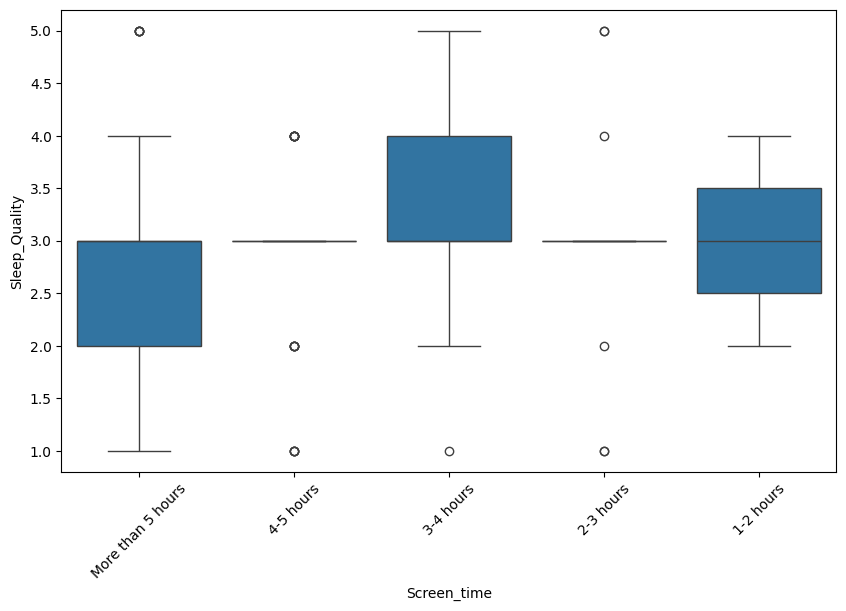

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x="Screen_time", y="Sleep_Quality", data=survey)

plt.xticks(
    rotation=45
)
plt.show()

In [92]:
print(high_confidence_rows["Screen_time"].value_counts())
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="Screen_time",
    y="Sleep_Quality",
    hue="Stress_Effect",
    data=survey,
    order=desired_order,
)
plt.xticks(rotation=45)
plt.show()

Screen_time
1.0    1503
2.0     477
0.0     120
Name: count, dtype: int64


NameError: name 'desired_order' is not defined

<Figure size 1000x600 with 0 Axes>

In [93]:
final_df

,Age,Screen_time,Sleep_Time,Sleep_Quality,Gender_Male,Academic_Level_Undergraduate
0,20,2.0,4.0,1,0,1
1,20,1.0,1.0,0,0,1
2,22,2.0,1.0,1,1,1
3,21,2.0,3.0,0,1,1
4,20,2.0,1.0,0,0,1
...,...,...,...,...,...,...
12216,24,2.0,2.0,1,0,1
12219,22,1.0,3.0,1,0,1
12221,19,1.0,3.0,1,1,1
12227,20,1.0,4.0,1,0,1


In [94]:
final_df = final_df[['Age', 'Screen_time', 'Sleep_Time',
                     'Gender_Male', 'Academic_Level_Undergraduate',
                     'Sleep_Quality']]
final_df

,Age,Screen_time,Sleep_Time,Gender_Male,Academic_Level_Undergraduate,Sleep_Quality
0,20,2.0,4.0,0,1,1
1,20,1.0,1.0,0,1,0
2,22,2.0,1.0,1,1,1
3,21,2.0,3.0,1,1,0
4,20,2.0,1.0,0,1,0
...,...,...,...,...,...,...
12216,24,2.0,2.0,0,1,1
12219,22,1.0,3.0,0,1,1
12221,19,1.0,3.0,1,1,1
12227,20,1.0,4.0,0,1,1


In [95]:
final_df.to_csv("final_df.csv", index=False)

## Models

## 1-logistic regression

In [96]:
print("Original distribution:")
print(final_df['Sleep_Quality'].value_counts())
print(f"Percentage: {final_df['Sleep_Quality'].value_counts(normalize=True) * 100}")

Original distribution:
Sleep_Quality
1    2114
0     153
Name: count, dtype: int64
Percentage: Sleep_Quality
1    93.250993
0     6.749007
Name: proportion, dtype: float64


In [97]:
x = final_df.iloc[:, :-1]
y = final_df.iloc[:, -1]


In [98]:
# Train test split
from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test =
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1)

#what is the shape of train and test data?
print('Number of rows in the total set: {}'.format(final_df.shape[0]))
print('Number of rows in the training set: {}'.format(X_train.shape[0]))
print('Number of rows in the test set: {}'.format(X_test.shape[0]))

Number of rows in the total set: 2267
Number of rows in the training set: 1700
Number of rows in the test set: 567


In [99]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().tolist())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_balanced.value_counts().tolist())

Before SMOTE: [1576, 124]
After SMOTE: [1576, 1576]


In [100]:
# Make logisitic Regerssion
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train_balanced, y_train_balanced)

LogisticRegression()

In [101]:
print("Accuracy on training set (balanced):", model.score(X_train_balanced, y_train_balanced))
print("Accuracy on test set (original):", model.score(X_test, y_test))

Accuracy on training set (balanced): 0.9102157360406091
Accuracy on test set (original): 0.9118165784832452


In [102]:
y_pred = model.predict(X_test)

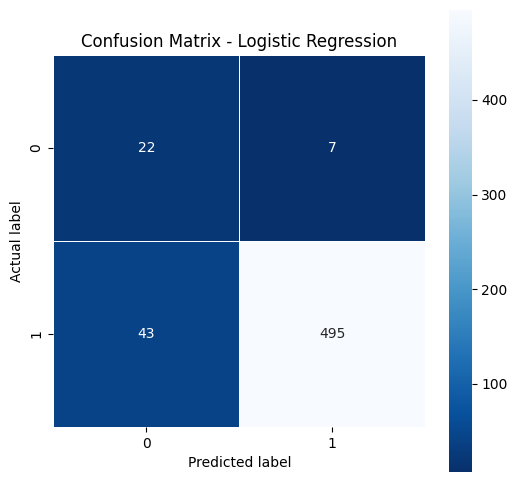

In [ ]:
from sklearn import metrics
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline



cm = metrics.confusion_matrix(y_true=y_test,
                              y_pred=y_pred,    
                              labels=[0, 1])


plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True,
            linewidths=.5, square=True, cmap='Blues_r', fmt='d')

plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [105]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n Classification Report:")
print(classification_report(y_test, y_pred))




 Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.76      0.47        29
           1       0.99      0.92      0.95       538

    accuracy                           0.91       567
   macro avg       0.66      0.84      0.71       567
weighted avg       0.95      0.91      0.93       567



## 2-Random Forest

Accuracy on training set (balanced): 0.9895304568527918
Accuracy on test  set  (original) : 0.9788359788359788


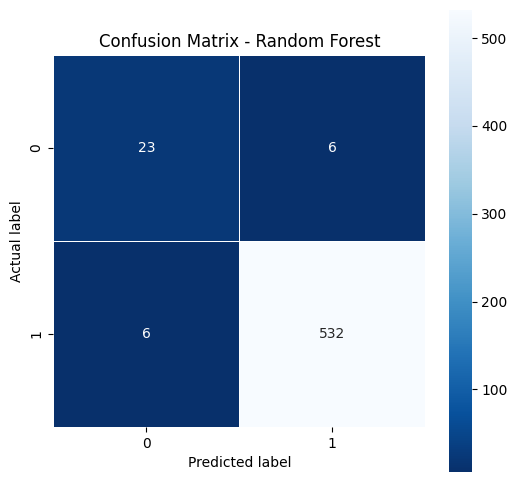


 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.99      0.99      0.99       538

    accuracy                           0.98       567
   macro avg       0.89      0.89      0.89       567
weighted avg       0.98      0.98      0.98       567



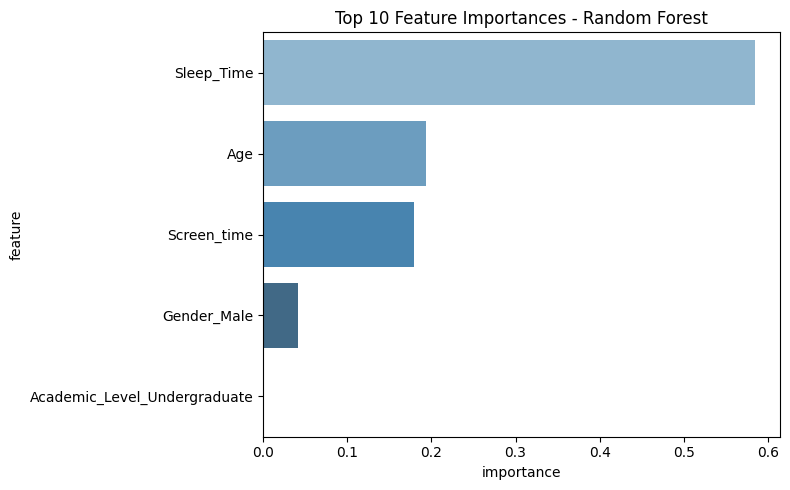

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # grow full trees (pruned by min_samples_leaf)
    min_samples_leaf=2,    # avoid over-fitting on tiny leaves
    class_weight='balanced',  # handle class imbalance
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
rf_model.fit(X_train_balanced, y_train_balanced)

# 2.Evaluate
print("Accuracy on training set (balanced):", rf_model.score(X_train_balanced, y_train_balanced))
print("Accuracy on test  set  (original) :", rf_model.score(X_test, y_test))

#3.Predictions
y_pred_rf = rf_model.predict(X_test)

#4.Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])

plt.figure(figsize=(6, 6))
sns.heatmap(cm_rf, annot=True, linewidths=.5, square=True,
            cmap='Blues_r', fmt='d')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

#5.Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred_rf))

#6. Feature Importance (top 10)
importances = rf_model.feature_importances_
feature_names = X_train_balanced.columns if hasattr(X_train_balanced, 'columns') \
                else [f'feature_{i}' for i in range(len(importances))]

import pandas as pd
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='importance', y='feature', palette='Blues_d')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

## 3-SVM

In [107]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report


In [109]:
dataset = pd.read_csv('final_df (1).csv')
X = dataset.drop(columns=['Sleep_Quality']).values
y = dataset['Sleep_Quality'].values

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

In [111]:
train_df = pd.DataFrame(X_train, columns=dataset.drop(columns=['Sleep_Quality']).columns)
train_df['Sleep_Quality'] = y_train

In [112]:
train_good_sleep = train_df[train_df['Sleep_Quality'] == 1]
train_bad_sleep = train_df[train_df['Sleep_Quality'] == 0]

In [113]:
train_good_downsampled = train_good_sleep.sample(n=len(train_bad_sleep), random_state=42)
balanced_train = pd.concat([train_good_downsampled, train_bad_sleep]).sample(frac=1, random_state=42)

In [114]:
balanced_train = pd.concat([train_good_downsampled, train_bad_sleep]).sample(frac=1, random_state=42)


X_train = balanced_train.drop(columns=['Sleep_Quality']).values
y_train = balanced_train['Sleep_Quality'].values

In [115]:
X_train = balanced_train.drop(columns=['Sleep_Quality']).values
y_train = balanced_train['Sleep_Quality'].values

In [116]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [117]:
classifier = SVC(kernel = 'rbf', C = 0.1, gamma = 'scale', random_state = 42)
classifier.fit(X_train, y_train)

SVC(C=0.1, random_state=42)

In [118]:
y_pred = classifier.predict(X_test)

In [119]:
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(cm)

--- Confusion Matrix ---
[[ 26   5]
 [ 10 413]]


In [120]:
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.72      0.84      0.78        31
           1       0.99      0.98      0.98       423

    accuracy                           0.97       454
   macro avg       0.86      0.91      0.88       454
weighted avg       0.97      0.97      0.97       454



## 4-descision tree

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1)

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',  
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [123]:
y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9647266313932981
              precision    recall  f1-score   support

           0       0.61      0.86      0.71        29
           1       0.99      0.97      0.98       538

    accuracy                           0.96       567
   macro avg       0.80      0.92      0.85       567
weighted avg       0.97      0.96      0.97       567



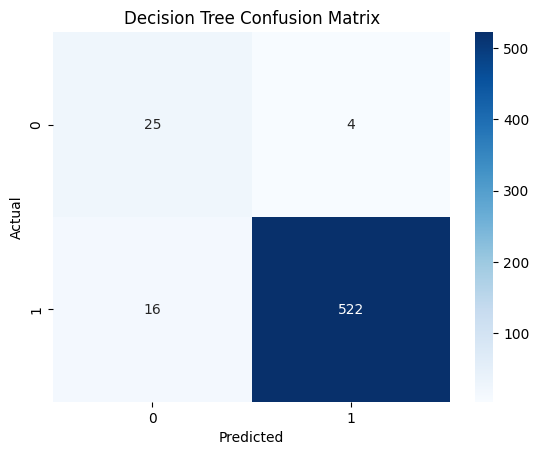

In [124]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## 5-Naive Bayes

In [125]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load your raw data file directly
df = pd.read_csv('final_df (1).csv')

# 2. Split into Train (80%) and Test (20%) first to prevent data leakage
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Sleep_Quality'])

# 3. Separate training data by class to balance it
train_good_sleep = train_df[train_df['Sleep_Quality'] == 1]
train_bad_sleep = train_df[train_df['Sleep_Quality'] == 0]

# Downsample the good sleep class to match the size of the bad sleep class
minority_size = len(train_bad_sleep)
train_good_downsampled = train_good_sleep.sample(n=minority_size, random_state=42)

# Combine them back together into a perfectly balanced training dataset
train_df_balanced = pd.concat([train_good_downsampled, train_bad_sleep], ignore_index=True)

# Shuffle the training rows randomly
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Separate features (X) and target (y) for the models
X_train = train_df_balanced.drop(columns=['Sleep_Quality'])
y_train = train_df_balanced['Sleep_Quality']

X_test = test_df.drop(columns=['Sleep_Quality'])
y_test = test_df['Sleep_Quality']

print("--- Training Set Size (Perfectly Balanced) ---")
print(y_train.value_counts())

print("\n--- Testing Set Size ( untouched Real World) ---")
print(y_test.value_counts())

--- Training Set Size (Perfectly Balanced) ---
Sleep_Quality
1    122
0    122
Name: count, dtype: int64

--- Testing Set Size ( untouched Real World) ---
Sleep_Quality
1    423
0     31
Name: count, dtype: int64


In [126]:
from sklearn.preprocessing import StandardScaler

# Initialize the standard scaler
scaler = StandardScaler()

# Scale the balanced training features and the raw test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled and normalized successfully!")

Features scaled and normalized successfully!


In [128]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train ONLY Gaussian Naive Bayes on the balanced data
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_pred = nb_model.predict(X_test_scaled)

print("Naive Bayes model trained perfectly on the balanced data!")

Naive Bayes model trained perfectly on the balanced data!


In [129]:
from sklearn.metrics import classification_report, confusion_matrix

print("=============================================")
print("          NAIVE BAYES PERFORMANCE            ")
print("=============================================")
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, nb_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, nb_pred))

          NAIVE BAYES PERFORMANCE            

--- Confusion Matrix ---
[[ 27   4]
 [ 67 356]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.29      0.87      0.43        31
           1       0.99      0.84      0.91       423

    accuracy                           0.84       454
   macro avg       0.64      0.86      0.67       454
weighted avg       0.94      0.84      0.88       454

